# 2 · Entrenamiento y evaluación

> **Tipo de ML:** `supervisado` · clase: `calor`

## Cómo está organizado este notebook

Hay dos cosas distintas que a menudo se confunden. **No son alternativas**, son fases diferentes:

| | Función | Qué come | Cuándo se corre | Qué produce |
|---|---|---|---|---|
| **Parte A** | `train_models` | `data/processed/` (X ya escalado) | **Siempre** que reentrenas | `.joblib` + MLflow → el modelo que se despliega |
| **Parte B** | `evaluate_models_temporal_cv` | `df` etiquetado (con `fecha`) | **A veces**, para validar | métricas media±std por año |
| **Parte B** | `tune_randomforest_temporal_cv` | `df` etiquetado (con `fecha`) | **A veces**, para decidir hiperparámetros | ranking de hiperparámetros |

**Regla mental:** la **Parte A es producción** (corre siempre, genera el modelo). La **Parte B es laboratorio** (corre de vez en cuando para *decidir*). El resultado del tuning **no se usa para predecir directamente**: se convierte en una decisión que se escribe a mano en `climasafeai/models/train_model.py`, y luego la Parte A lo usa. Ejemplo real: de ahí salió el `max_depth=12` actual del RandomForest.

👉 Si solo quieres reentrenar con los hiperparámetros ya decididos, corre **solo la Parte A**. La Parte B es opcional y solo hace falta cuando cambias las features, añades años de datos, o quieres re-tunear.

## Decisiones de diseño

Las decisiones que gobiernan este notebook (ver detalle en `documenatcion/conclusiones_modelos.md`):

- **Objetivo = AVISO, no "accuracy bonita".** Se **prioriza el recall de las clases de riesgo** (1 precaución, 2 peligro): son **vidas**, así que preferimos **falsos positivos** (avisar de más) antes que **falsos negativos** (no avisar de un día peligroso). Por eso el modelo se elige por **`Rec_riesgo`** (sección 7), no por accuracy ni F1 ponderado (dominados por la clase `seguro` ~90% de los días).
- **XGBoost SIEMPRE con `sample_weight` balanceado.** Sin pesos colapsa a la clase mayoritaria (recall de riesgo ~0.00, "nunca avisa"). El peso lo aplica `train_models`.
- **Hiperparámetros del RandomForest por clase** (calor `max_depth=12` / frío `8`): el frío generaliza mejor con árboles más superficiales por su señal más sostenida.
- **Features de persistencia (lags)**: `wind_chill_mean_roll7`, `dias_consec_bajo_umbral`, etc. — el frío es acumulativo (la *racha* mata, no el día suelto). Fueron la mayor mejora del proyecto.
- **Modelo desplegado**: **calor → XGBoost** (mejor en todo); **frío → RandomForest** (capta más días de riesgo).

## 0. Entorno


In [1]:
# Verificar que el entorno está activo
import sys
print(f'Python: {sys.version}')
import xgboost; print(f'XGBoost: {xgboost.__version__}')



Python: 3.13.5 (main, May  5 2026, 21:05:52) [GCC 14.2.0]
XGBoost: 3.3.0


## 1. Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from climasafeai.utils.paths import (
    PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR,
)

# --- Parte A: entrenamiento y evaluación "de producción" ---
from climasafeai.models.train_model import train_models, load_models
from climasafeai.models.predict_model import evaluate_models, predict_new, DECISION_THRESHOLD
from climasafeai.visualization.visualize import plot_feature_importance

# --- Parte B: validación temporal y tuning (opcional, ver más abajo) ---
from climasafeai.models.temporal_cv import (
    evaluate_models_temporal_cv,
    resumen_temporal_cv,
    tune_randomforest_temporal_cv,
)

## 2. Cargar datos procesados


In [3]:
# ── Carga de datos procesados ───────────────────────────────────────────────
# Si el pipeline aún no se ha ejecutado, corre primero: make data && make features
try:
    
    X_train = pd.read_csv(PROCESSED_DATA_DIR / 'X_train_calor.csv')
    X_test  = pd.read_csv(PROCESSED_DATA_DIR / 'X_test_calor.csv')
    y_train = pd.read_csv(PROCESSED_DATA_DIR / 'y_train_calor.csv').squeeze()
    y_test  = pd.read_csv(PROCESSED_DATA_DIR / 'y_test_calor.csv').squeeze()
    print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
    print(f'Clases: {sorted(y_train.unique().tolist())}')
    print(f'Balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')
    
except FileNotFoundError as _e:
    raise FileNotFoundError(
        f"Datos no encontrados: {_e}\n"
        "Ejecuta primero: make data && make features\n"
        "O desde este notebook: !make data features"
    ) from _e


Train: (137925, 19)  |  Test: (34470, 19)
Clases: [0, 1, 2]
Balance (train): {0: 0.898, 1: 0.055, 2: 0.046}


# Parte A · Entrenamiento final (camino habitual)

Entrena los modelos con los hiperparámetros **ya decididos** (los que viven en `train_model.py`) sobre los datos procesados, los guarda en `models/` + MLflow, y los evalúa en el test. **Esta es la parte que corres siempre.**

## 3. Configuración


Modelo activo: `RandomForest`. Cambia `model_type` en json y regenera para entrenar otro.



In [4]:

# Configuración: model_type activo = 'RandomForest'
# tune_knn=True  → busca el k óptimo para KNN (lento en datasets grandes)
# cv_evaluate=True → muestra F1 5-fold de cada modelo antes de guardar
TUNE_KNN    = True
CV_EVALUATE = True


## 4. Entrenar


In [5]:
# ejecutar make mlflow
models = train_models(X_train, y_train, tune_knn=TUNE_KNN, cv_evaluate=CV_EVALUATE, clase='calor')

--> Entrenando modelos de clasificacion (clase='calor')...
    [KNN] best_params cargados desde caché: {'n_neighbors': 7}
    AVISO: no se pudo conectar al tracking server de MLflow (API request to http://localhost:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=climasafeai (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused"))).
    Usando tracking local (sqlite:////home/cacelas/Documentos/anfaia/ClimaSafeAI/mlflow.db) en su lugar.
    [RandomForest] entrenando...
      F1_weighted 5-fold CV: 0.842


2026/07/09 09:32:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


      Guardado → RandomForest_calor.joblib


2026/07/09 09:33:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/09 09:33:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'climasafeai_RandomForest_calor' already exists. Creating a new version of this model...
Created version '2' of model 'climasafeai_RandomForest_calor'.


    [XGBoost] entrenando...


...

    [KNN] entrenando...
      F1_weighted 5-fold CV: 0.892


2026/07/09 09:33:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


      Guardado → KNN_calor.joblib


2026/07/09 09:33:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/09 09:33:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'climasafeai_KNN_calor' already exists. Creating a new version of this model...
Created version '2' of model 'climasafeai_KNN_calor'.


--> 3 modelos guardados en /home/cacelas/Documentos/anfaia/ClimaSafeAI/models


## 5. Evaluar


In [6]:

threshold  = DECISION_THRESHOLD   # ajustar si clases muy desbalanceadas
df_results = evaluate_models(
    models, X_train, y_train, X_test, y_test, threshold=threshold
)
df_results.sort_values('F1_test', ascending=False)



  Evaluación — clasificacion (umbral=0.5)

--- RandomForest ---
  Accuracy  → train: 0.829 | test: 0.764
  F1 (w)    → train: 0.863  | test: 0.815
  Precision → 0.902  | Recall → 0.764
  F1_macro  → 0.530  | Rec_riesgo (clases 1..n) → 0.599

              precision    recall  f1-score   support

           0       0.99      0.79      0.87     30446
           1       0.16      0.55      0.25      1842
           2       0.37      0.65      0.47      2182

    accuracy                           0.76     34470
   macro avg       0.50      0.66      0.53     34470
weighted avg       0.90      0.76      0.82     34470

    cm_RandomForest.png guardado

--- XGBoost ---
  Accuracy  → train: 0.842 | test: 0.783
  F1 (w)    → train: 0.872  | test: 0.828
  Precision → 0.904  | Recall → 0.783
  F1_macro  → 0.546  | Rec_riesgo (clases 1..n) → 0.614

              precision    recall  f1-score   support

           0       0.99      0.80      0.89     30446
           1       0.18      0.55      

,Modelo,Acc_train,Acc_test,F1_train,F1_test,Prec_test,Rec_test,F1_macro,Rec_riesgo
2,KNN,1.0000,0.8818,1.0000,0.8687,0.8602,0.8818,0.5013,0.2288
1,XGBoost,0.8422,0.7831,0.8723,0.8278,0.9044,0.7831,0.5464,0.6138
0,RandomForest,0.8291,0.7642,0.8628,0.8151,0.9024,0.7642,0.5299,0.5994


## 6. Importancia de variables


    feature_importance.png guardado


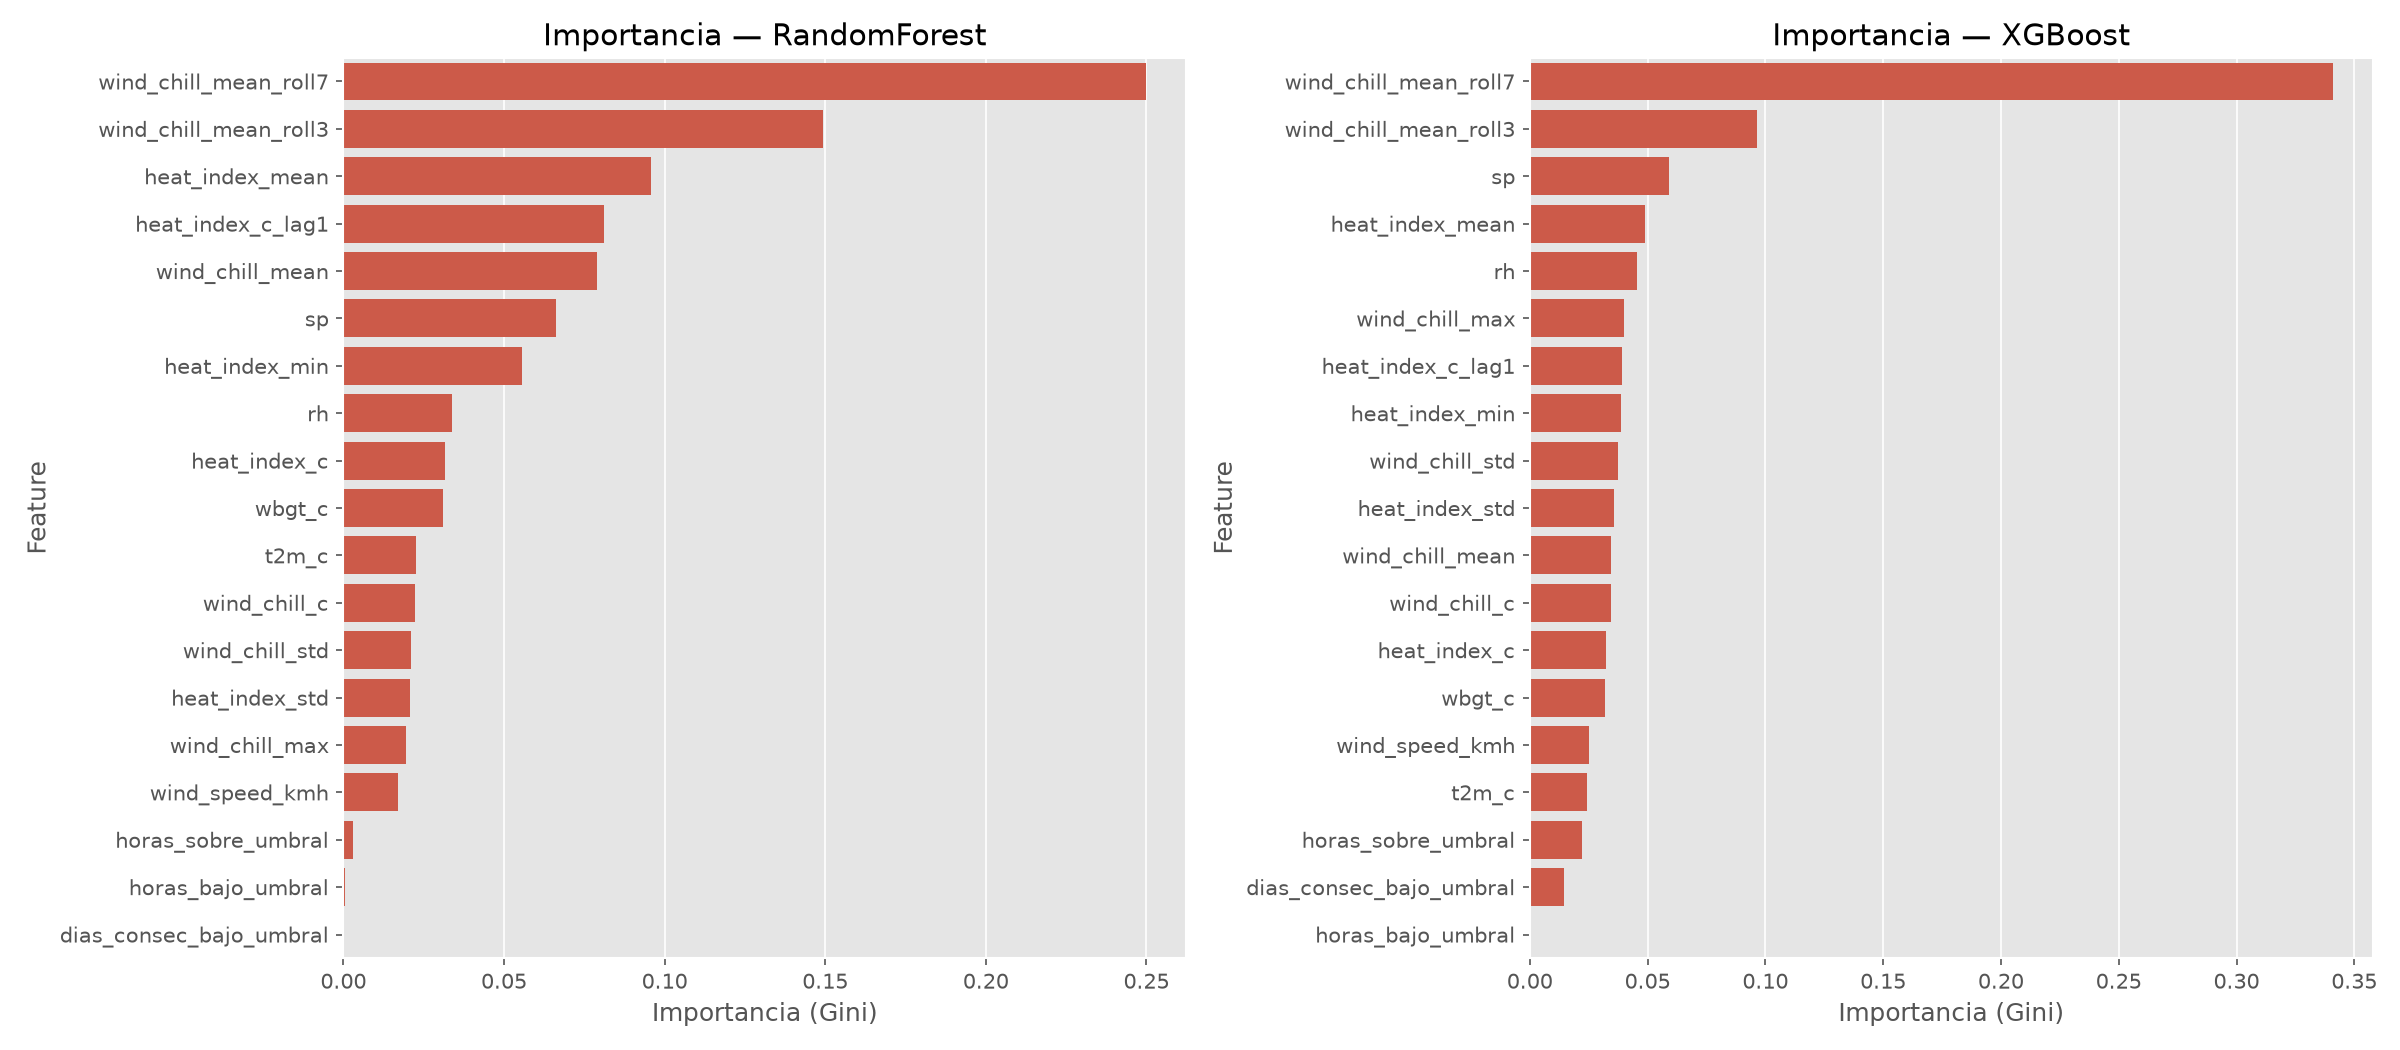

In [7]:
# Nombres REALES de las features desde el artifact. Los CSV de X están escalados
# y pierden los nombres (X_train.columns daría 0,1,2,...), así que la importancia
# saldría numerada. feature_names_calor.joblib los guarda en el mismo orden.
from climasafeai.utils.paths import ARTIFACTS_DIR
feature_names = joblib.load(ARTIFACTS_DIR / 'feature_names_calor.joblib')
plot_feature_importance(models, feature_names)
from IPython.display import Image
Image(FIGURES_DIR / 'feature_importance.png')

## 7. Predicción sobre nuevos datos

Selecciona el modelo a desplegar. **Ojo con el criterio:** el `F1_test`/`Rec_test` del resumen son *ponderados* y están dominados por la clase 0 (seguro, ~90% de los días), así que ordenar por ahí elige XGBoost/KNN pese a su recall pésimo en las clases de riesgo. Para un sistema de aviso, mira el recall de las clases 1 y 2 en los `classification_report` de la sección 5 antes de fijar el modelo.

In [8]:
# DECISIÓN DE DISEÑO — selección por Rec_riesgo (no por F1_macro ni accuracy).
# Esto es un sistema de AVISO y hablamos de VIDAS: preferimos un falso positivo
# (avisar de más) antes que un falso negativo (no avisar de un día peligroso).
# Por eso elegimos el modelo que MÁS días de riesgo capta = mayor Rec_riesgo
# (recall medio de las clases 1=precaución y 2=peligro), aceptando más falsas
# alarmas (menos precisión). Para calor el ganador es XGBoost (mejor en todo).
best_name  = df_results.sort_values('Rec_riesgo', ascending=False).iloc[0]['Modelo']
best_model = models[best_name]
print(f'Modelo desplegado (máx. Rec_riesgo): {best_name}')
print(df_results[['Modelo', 'Rec_riesgo', 'F1_macro', 'F1_test', 'Acc_test']].to_string(index=False))

# Persistir el modelo ELEGIDO como el desplegado de esta clase (antes había que
# fijarlo a mano). Los .joblib de cada modelo siguen guardados namespaceados.
joblib.dump(best_model, MODELS_DIR / 'modelo_desplegado_calor.joblib')
print(f'→ guardado modelo_desplegado_calor.joblib  ({best_name})')

# Predecir sobre nuevos datos:
# from climasafeai.features.build_features import process_input
# X_new   = process_input(df_nuevos)          # clase='calor' por defecto
# preds, probs = predict_new(best_model, X_new, threshold=threshold)

Modelo desplegado (máx. Rec_riesgo): XGBoost
      Modelo  Rec_riesgo  F1_macro  F1_test  Acc_test
     XGBoost      0.6138    0.5464   0.8278    0.7831
RandomForest      0.5994    0.5299   0.8151    0.7642
         KNN      0.2288    0.5013   0.8687    0.8818
→ guardado modelo_desplegado_calor.joblib  (XGBoost)


# Parte B · Validación temporal y tuning (opcional)

> **No hace falta correr esto en cada entrenamiento.** Es la parte de "laboratorio": sirve para (1) comprobar que los modelos generalizan bien de un año a otro, y (2) *decidir* hiperparámetros. Lo que salga de aquí se copia a mano a `climasafeai/models/train_model.py` — no se usa para predecir directamente.

**Cuándo correrla:** cuando añadas años de datos, cambies las features, o quieras re-tunear un modelo.

A diferencia de la Parte A, esto necesita el **dataset etiquetado con `fecha`** (`dataset_calor_labeled.parquet`, que genera el notebook de procesado `0-1`), porque la validación temporal hace su propio preprocesado por año para no filtrar información del futuro al pasado.

In [9]:
# ── Cargar el dataset etiquetado (con 'fecha') que genera el notebook 0-1 ────
_labeled_path = PROCESSED_DATA_DIR / 'dataset_calor_labeled.parquet'
if not _labeled_path.exists():
    raise FileNotFoundError(
        f"No existe {_labeled_path.name}.\n"
        "Ejecuta primero el notebook de procesado 0-1 (sección 4, "
        "'Guardar dataset etiquetado'), que lo genera."
    )
df_labeled = pd.read_parquet(_labeled_path)
_años = sorted(pd.to_datetime(df_labeled['fecha']).dt.year.unique().tolist())
print(f"Dataset etiquetado: {df_labeled.shape}  |  años disponibles: {_años}")

Dataset etiquetado: (172395, 25)  |  años disponibles: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## B.1 · Robustez por años (los 3 modelos)

Entrena con todos los años hasta N-1 y evalúa en el año N, deslizando N. Da media ± desviación por modelo, en vez de depender de si el último tramo de fechas salió fácil o difícil por casualidad. `knn_k=7` es el k ya cacheado (ver `best_params_KNN.joblib`).

In [10]:
resultados_cv = evaluate_models_temporal_cv(
    df_labeled,
    target_col='clase_riesgo_calor',
    clase='calor',
    knn_k=7,              # mismo k cacheado que usa train_models()
)
resumen_temporal_cv(resultados_cv)   # media ± std por modelo a lo largo de los años

--> Fold: train 2016-2018 (49320 filas) | test 2019 (16425 filas)
--> Fold: train 2016-2019 (65745 filas) | test 2020 (16470 filas)
--> Fold: train 2016-2020 (82215 filas) | test 2021 (16425 filas)
--> Fold: train 2016-2021 (98640 filas) | test 2022 (16425 filas)
--> Fold: train 2016-2022 (115065 filas) | test 2023 (16425 filas)
--> Fold: train 2016-2023 (131490 filas) | test 2024 (16470 filas)
--> Fold: train 2016-2024 (147960 filas) | test 2025 (16425 filas)
--> Fold: train 2016-2025 (164385 filas) | test 2026 (8010 filas)


,Modelo,Acc_train_mean,Acc_train_std,Acc_test_mean,Acc_test_std,F1_train_mean,F1_train_std,F1_test_mean,F1_test_std,Prec_test_mean,Prec_test_std,Rec_test_mean,Rec_test_std
0,KNN,1.000000,0.000000,0.904490,0.023753,1.000000,0.000000,0.891683,0.026310,0.885120,0.027345,0.904490,0.023753
1,RandomForest,0.836958,0.016479,0.804654,0.031444,0.867509,0.011756,0.847790,0.028529,0.918251,0.019014,0.804654,0.031444
2,XGBoost,0.939103,0.008496,0.915188,0.022769,0.930421,0.011540,0.903578,0.024440,0.897259,0.025966,0.915188,0.022769


## B.2 · Re-tuning de RandomForest (solo si hace falta)

Busca hiperparámetros de RandomForest con la **misma** validación temporal por años (no un GridSearch aleatorio, que sería incoherente con datos temporales). `scoring='Rec_test'` prioriza el recall de las clases de riesgo, coherente con un sistema de aviso.

⚠️ El resultado **no** se aplica automáticamente: mira la primera fila del ranking y, si mejora lo que ya hay, copia esos hiperparámetros al diccionario `RandomForest` de `climasafeai/models/train_model.py`. Después vuelve a correr la Parte A.

In [11]:
ranking_rf = tune_randomforest_temporal_cv(
    df_labeled,
    target_col='clase_riesgo_calor',
    clase='calor',
    scoring='Rec_test',   # 'F1_test' si prefieres equilibrio global en vez de recall
)
# La primera fila es la recomendada; 'params' es lo que copiarías a train_model.py
ranking_rf[['params', 'Rec_test_mean', 'F1_test_mean', 'Acc_test_mean', 'Prec_test_mean']].head()

--> Probando RandomForest con {'max_depth': 10, 'class_weight': None, 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando RandomForest con {'max_depth': 10, 'class_weight': 'balanced', 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando RandomForest con {'max_depth': 15, 'class_weight': None, 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando RandomForest con {'max_depth': 15, 'class_weight': 'balanced', 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando RandomForest con {'max_depth': 20, 'class_weight': None, 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando RandomForest con {'max_depth': 20, 'class_weight': 'balanced', 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando RandomForest con {'max_depth': None, 'class_weight': None, 'n_estimators': 200, 'max_features': 'sqrt', 'max_samples': 0.8}...
--> Probando R

,params,Rec_test_mean,F1_test_mean,Acc_test_mean,Prec_test_mean
0,"{'max_depth': 20, 'class_weight': None, 'n_est...",0.913835,0.899587,0.913835,0.892686
1,"{'max_depth': None, 'class_weight': None, 'n_e...",0.913703,0.899772,0.913703,0.892831
2,"{'max_depth': 15, 'class_weight': None, 'n_est...",0.913654,0.897501,0.913654,0.890295
3,"{'max_depth': 10, 'class_weight': None, 'n_est...",0.913238,0.893398,0.913238,0.886372
4,"{'max_depth': None, 'class_weight': 'balanced'...",0.886334,0.896450,0.886334,0.909439


## 8. Profiling (opcional)

Si el entrenamiento es lento, identifica dónde se va el tiempo:

```bash
make profile
snakeviz reports/profile.prof
```
